# Question 3

In [3]:
!pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import networkx as nx
G = nx.read_gml("data/MIT8.gml")

print("Attributs du graphe (G.graph) :")
print(G.graph)

print("\nAttributs des nœuds (exemple du premier nœud) :")
first_node = next(iter(G.nodes))
print(G.nodes[first_node])

print("\nAttributs des arêtes (exemple de la première arête) :")
first_edge = next(iter(G.edges))
print(G.edges[first_edge])

Attributs du graphe (G.graph) :
{}

Attributs des nœuds (exemple du premier nœud) :
{'student_fac': 1, 'gender': 2, 'major_index': 8, 'second_major': 22, 'dorm': 0, 'year': 2009, 'high_school': 23574}

Attributs des arêtes (exemple de la première arête) :
{}


Networks: 100%|██████████| 100/100 [29:20<00:00, 17.60s/it]

Réseaux analysés: 100


,network,n,degree,student_fac,major_index,dorm,gender
13,Caltech36,769,-0.000390,0.244079,0.034719,0.349153,0.046331
50,Reed98,962,-0.000548,0.262337,0.042118,0.145600,0.020110
26,Haverford76,1446,-0.000591,0.380881,0.034443,0.125015,0.053742
55,Simmons81,1518,-0.000398,0.318609,0.061288,0.167731,0.004645
58,Swarthmore42,1659,-0.000253,0.346994,0.039752,0.102821,0.053833


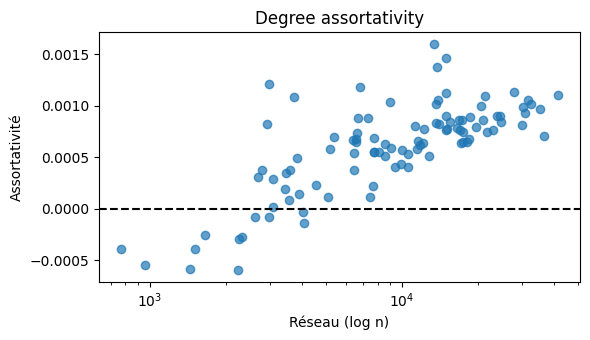

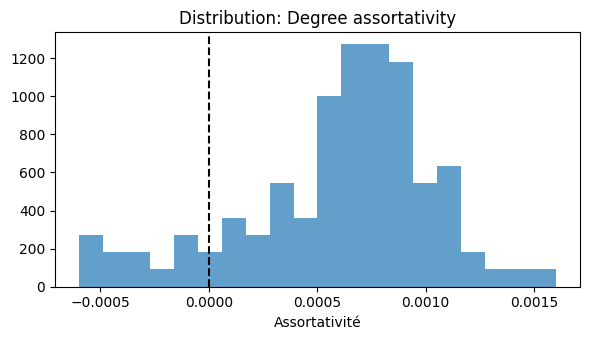

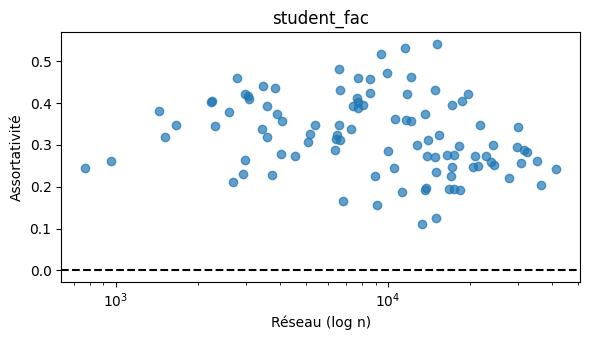

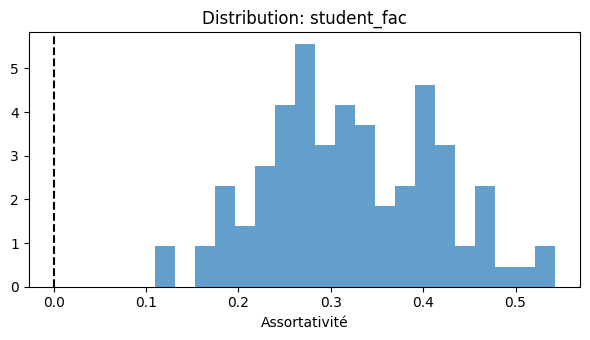

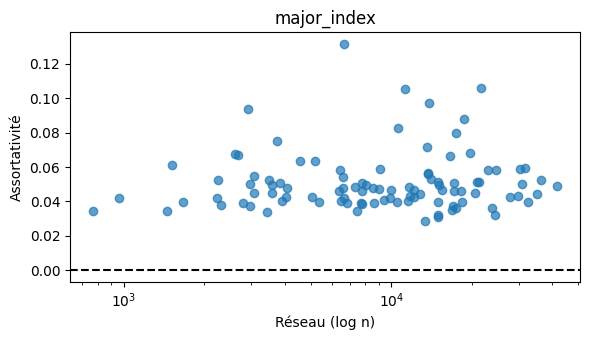

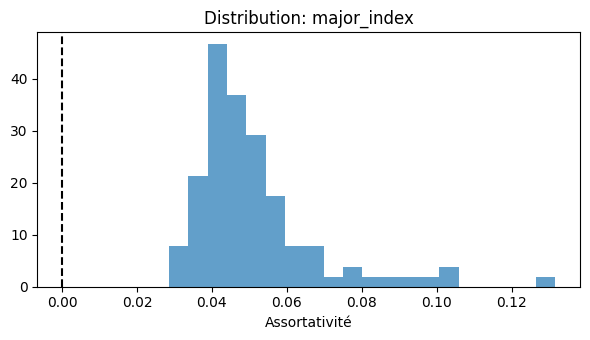

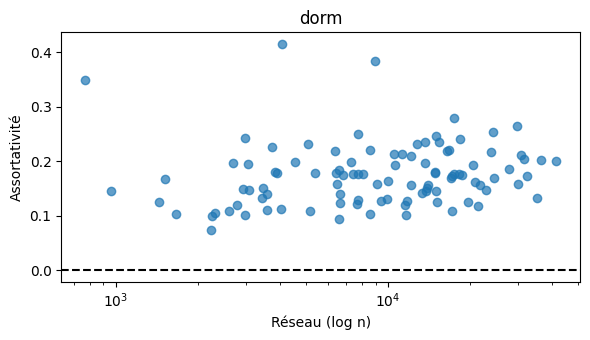

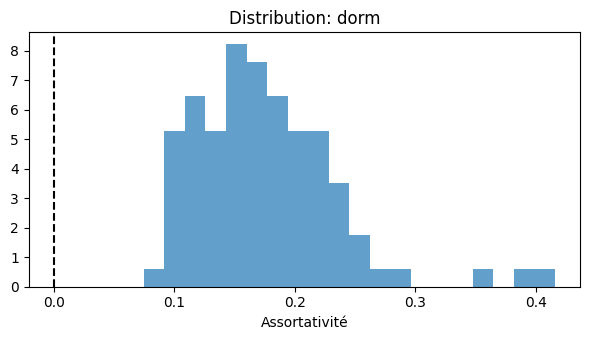

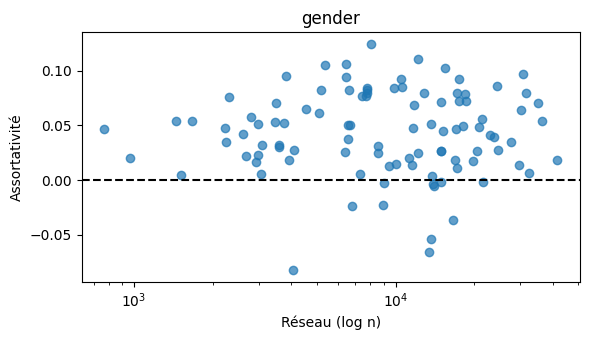

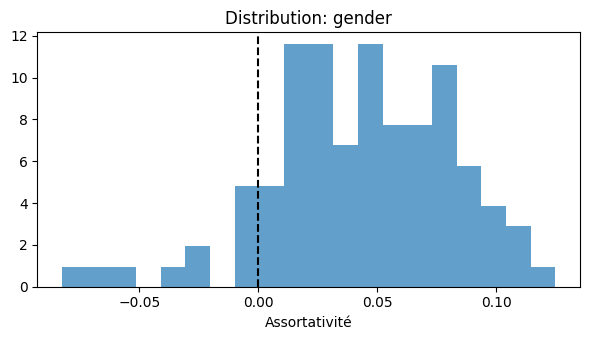

In [ ]:
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

DATA_DIR = Path('data')
files = sorted(DATA_DIR.glob('*.gml'), key=lambda p: p.name)
rows = []
attrs = ['student_fac', 'major_index', 'dorm', 'gender']


# Il existe une fonction nx qui fait la même chose mais cette fonction est donnée dans le doc 3
def assortativity_from_mixing_matrix(mixing_matrix):
    sum_row = mixing_matrix.sum(axis=1)
    sum_col = mixing_matrix.sum(axis=0)
    expected_value = float(np.dot(sum_row, sum_col)) # = normalized mixig matrix
    denominator = 1.0 - expected_value
    return (float(np.trace(mixing_matrix)) - expected_value) / denominator


for path in tqdm(files, desc='Networks'):
    name = path.stem
    
    G = nx.read_gml(str(path))
    n = G.number_of_nodes()
    row = {'network': name, 'n': n}

    degree_mixing = nx.degree_mixing_matrix(G, normalized=True) ## pas compliqué de faire la fonction à la main sinon, voir quesiton 2
    row['degree'] = assortativity_from_mixing_matrix(degree_mixing)

    for a in attrs:
        attr_mixing = nx.attribute_mixing_matrix(G, a, normalized=True)
        row[a] = assortativity_from_mixing_matrix(attr_mixing)
    rows.append(row)


df = pd.DataFrame(rows).sort_values('n')
print('Réseaux analysés:', len(df))


def plot_diag(col, title=None):
    plt.figure(figsize=(6, 3.5))
    # scatter (log-x)
    plt.scatter(df['n'], df[col], alpha=0.7)
    plt.xscale('log')
    plt.axhline(0, color='k', linestyle='--')
    plt.xlabel('Réseau (log n)')
    plt.ylabel('Assortativité')
    plt.title(title or f'{col} vs n')
    plt.tight_layout()
    plt.show()

    # distribution
    plt.figure(figsize=(6, 3.5))
    series = df[col].dropna()
    if len(series) > 0:
        plt.hist(series, bins=20, density=True, alpha=0.7)
    plt.axvline(0, color='k', linestyle='--')
    plt.xlabel('Assortativité')
    plt.title('Distribution: ' + (title or col))
    plt.tight_layout()
    plt.show()


# run plots
plot_diag('degree', 'Degré d\'associativité')
for a in attrs:
    plot_diag(a, a)